# Emergency Ambulance Dispatch & Routing
### Team Project 7 — ENSIA Introduction to AI

This notebook contains the full implementation of:
- **A\* and Real-Time A\***: Pair A (Allali Bouchra/Hamadache Thawriyya)
- **Hill Climbing standby optimization**: Pair B (Moumani Malek Nourhene /Immessaoudene Malak Ikram)
- **Greedy vs A\*-based dispatch + simulation loop**: Pair C (Bentata Ikram Amina/Ferhaoui Amina)

In [13]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: d:\School\S4\Intro to Ai\Project\Codespace\PreFinal\ambulance-dispatch


In [14]:
from src.core.simulation_engine import SimulationEngine
from src.core.graph import SimpleGraph
from src.core.ambulance import Ambulance, AmbulanceState
from src.core.emergency import Emergency
from src.core.hospital import Hospital

from src.simulation.dispatcher import Dispatcher, ResponseLogger
from src.simulation.poisson_generator import PoissonEmergencyGenerator
from src.simulation.event_queue import EventQueue
from src.simulation.surge_scenarios import SurgeScenario, run_surge_test

from src.evaluation.comparison_runner import ComparisonRunner

from src.visualization.dashboard import SimulationDashboard
from src.visualization.histograms import (
    plot_response_time_comparison,
    plot_hill_climbing_convergence,
)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.facecolor'] = '#110810'
print("All imports OK.")

All imports OK.


---
## 1. Road Graph Construction and Traffic Model
Built by Pair B. Loads the road network from `data/map.json`.

In [15]:
# Updated by Member 6 to use map.json for real data
graph = SimpleGraph("../data/map.json")
print(f"Graph loaded: {len(graph.nodes)} nodes, {len(graph.edges)} edges")

Graph loaded: 53616 nodes, 130871 edges


---
## 2. Simulation Engine Initialization
Initialises the event engine, Poisson generator bound to the real map,
and places hospitals and depots on actual graph nodes.

In [16]:
SIMULATION_DURATION = 300
LAMBDA_RATE = 0.05

sim = SimulationEngine(
    duration=SIMULATION_DURATION,
    lambda_rate=LAMBDA_RATE,
    graph=graph
)

sim.generator = PoissonEmergencyGenerator.from_graph(
    lambda_rate=LAMBDA_RATE,
    graph=graph
)

sim.initialize()

print("Hospitals placed:")
for hospital in sim.hospitals:
    print(f"  {hospital}  node_id={hospital.node_id}")

print("\nDepot nodes:", sim.depots)
print("Ambulances:", sim.ambulances)
print("Event queue size after init:", sim.event_queue.size())

Hospitals placed:
  Hospital(0, 'Dispensaire', 0/6)  node_id=693026336
  Hospital(1, 'Centre de Santé Diar Djemaa', 0/6)  node_id=4331692925
  Hospital(2, 'Polyclinique Verdier', 0/6)  node_id=689778474
  Hospital(3, 'Dispensaire مستوصف', 0/6)  node_id=691206048
  Hospital(4, 'Polyclinique Les Sources', 0/6)  node_id=2804815537
  Hospital(5, 'Centre de Soins', 0/6)  node_id=961009932
  Hospital(6, 'Polyclinique', 0/6)  node_id=975497913
  Hospital(7, 'عيادة القدس', 0/6)  node_id=321122225
  Hospital(8, 'Etablissement public de santé de Birtouta', 0/6)  node_id=1088078891
  Hospital(9, 'Centre de santé baba ali', 0/6)  node_id=529510862
  Hospital(10, 'Polyclinique étatique', 0/6)  node_id=386932032
  Hospital(11, 'Clinique Lotus', 0/6)  node_id=2244626790
  Hospital(12, 'dispensaire', 0/6)  node_id=6627625189
  Hospital(13, 'Centre de soin', 0/6)  node_id=2374433197
  Hospital(14, 'Polyclinique diascan plus', 0/6)  node_id=479665000
  Hospital(15, 'Clinique hémodialyse', 0/6)  node_id=

---
## 3. Emergency Simulation Run
Event loop driven by a priority queue and Poisson arrivals.
Each emergency snaps to the nearest real graph node by coordinate distance.

In [17]:
sim.run()

print(f"\n--- Simulation complete ---")
print(f"Total emergencies processed : {len(sim.processed_events)}")
print(f"Assigned                    : {sum(1 for e in sim.processed_events if e.assigned)}")
print(f"Unassigned (no ambulance)   : {sum(1 for e in sim.processed_events if not e.assigned)}")

[6.01] Emergency at (3.05, 36.65) -> node 10018126084


AttributeError: 'Edge' object has no attribute 'travel_time'

---
## 4. Ambulance State Machine and Dispatch Logic
Pair C: Ambulance class and state machine and comparison framework.

In [18]:
print("Ambulance states after simulation:")
for amb in sim.ambulances:
    print(f"  {amb}")

Ambulance states after simulation:
  Ambulance(id=1, state=IDLE, node=691187211)
  Ambulance(id=2, state=AT_SCENE, node=10018126084)


In [19]:
idle_ambulances = [amb for amb in sim.ambulances if amb.is_available()]
print("Idle ambulances (repositioned by Hill Climbing):")
for amb in idle_ambulances:
    print(f"  Ambulance {amb.id} standby node {amb.current_node}")
if not idle_ambulances:
    print("  (all ambulances still active)")

Idle ambulances (repositioned by Hill Climbing):
  Ambulance 1 standby node 691187211


---
## 5. A\* and Real-Time A\* Routing
Pair A. (The finilized code ykoun hna)

In [20]:
# from src.algorithms.astar import astar
# path, cost = astar(start_node, goal_node)
# print(f"Path: {path}  Cost: {cost:.3f}")
print("A* placeholder")

A* placeholder


---
## 6. Hill Climbing Standby Optimization
Pair B. Optimises idle ambulance standby positions using Hill Climbing.

In [21]:
# Updated by Member 6 for correct import and instantiation
from src.algorithms.StandbyManager import StandbyManager
from src.algorithms.hill_climbing import HillClimbing
from src.algorithms.astar import astar

optimizer = StandbyManager(HillClimbing(graph, lambda s, g: astar(s, g)[1]))
print("StandbyManager initialized.")

StandbyManager initialized.


---
## 7. Dispatch Method Comparison — Greedy vs A\*
Runs the same processed emergency sequence under both methods.

In [22]:
fixed_emergencies = list(sim.processed_events)

base_ambs = [
    Ambulance(id=i, start_node=sim.depots[i % len(sim.depots)])
    for i in range(len(sim.ambulances))
]

runner = ComparisonRunner(
    base_ambulances=base_ambs,
    hospitals=sim.hospitals,
    emergencies=fixed_emergencies,
    astar_fn=None,
)

results = runner.run(verbose=True)


  DISPATCH METHOD COMPARISON
  Emergency count: 1
  Metric                       Greedy  A* Dispatch
----------------------------------------------------
  Avg response time      9326938873.0 9326938873.0
  Min response time      9326938873.0 9326938873.0
  Max response time      9326938873.0 9326938873.0
  Emergencies served                1            1
  Winner: Greedy  (0.0% difference)



---
## 8. Surge Scenario — Simultaneous Emergency Injection
Injects emergencies simultaneously and verifies the
1-patient-per-ambulance capacity constraint.

In [23]:
surge_sim = SimulationEngine(
    duration=SIMULATION_DURATION,
    lambda_rate=LAMBDA_RATE,
    graph=graph
)
surge_sim.generator = PoissonEmergencyGenerator.from_graph(
    lambda_rate=LAMBDA_RATE, graph=graph
)
surge_sim.initialize()

surge_result = run_surge_test(
    sim_engine=surge_sim,
    surge_count=7,
    surge_at_time=50.0
)

print("\nSurge test result:")
print(f"  Surge IDs injected : {surge_result['surge_ids']}")
print(f"  Capacity constraint: {'PASSED' if surge_result['capacity_ok'] else 'VIOLATED'}")
print(f"  Events processed   : {surge_result['processed_count']}")

[SURGE @ t=50.00] Injected 7 emergencies: IDs [5, 6, 3, 8, 2, 4, 7]

--- Surge injected: 7 emergencies ---
Queue size after injection: 8



ZeroDivisionError: division by zero

---
## 9. Evaluation and Visualizations
Dashboard, response time histogram, Hill Climbing convergence plot.

d:\School\S4\Intro to Ai\Project\Codespace\PreFinal\ambulance-dispatch\src\visualization\dashboard.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(states, rotation=15, ha="right",
d:\School\S4\Intro to Ai\Project\Codespace\PreFinal\ambulance-dispatch\src\visualization\dashboard.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontfamily="monospace",
d:\School\S4\Intro to Ai\Project\Codespace\PreFinal\ambulance-dispatch\src\visualization\dashboard.py:207: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hosp_ids, fontfamily="monospace",


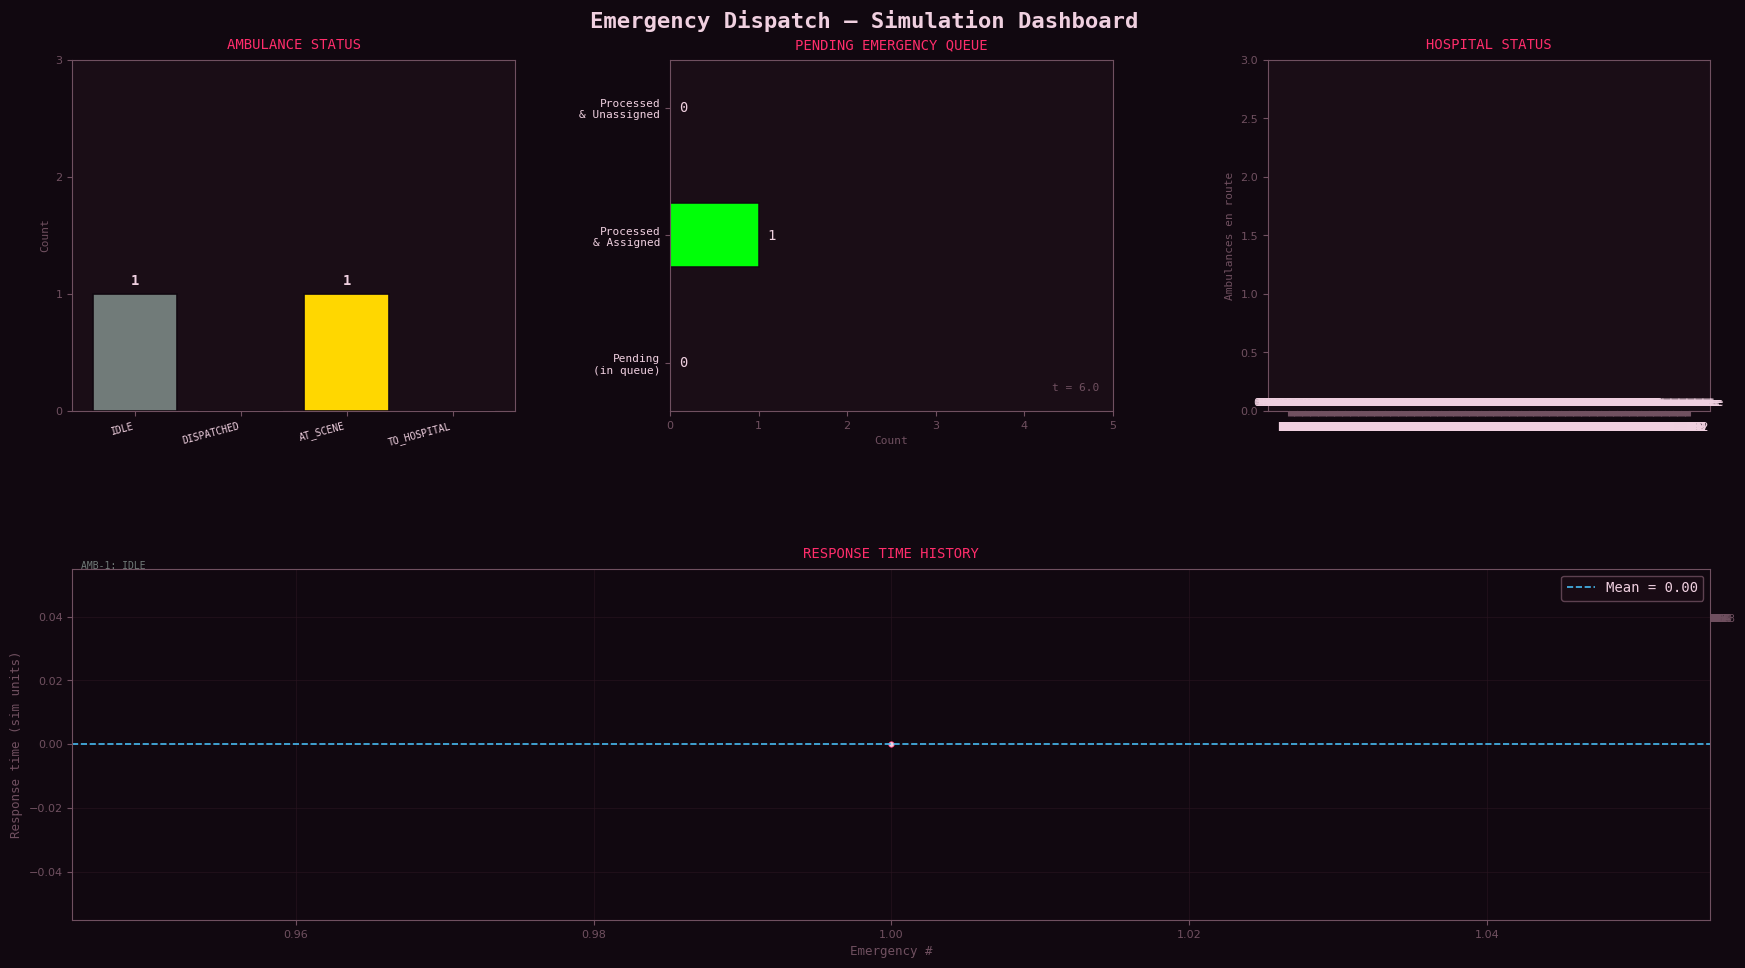

In [24]:
dashboard = SimulationDashboard(figsize=(18, 10))
dashboard.render_snapshot(sim, title="Emergency Dispatch — Simulation Dashboard")

d:\School\S4\Intro to Ai\Project\Codespace\PreFinal\ambulance-dispatch\src\visualization\histograms.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.18, 1, 0.95])


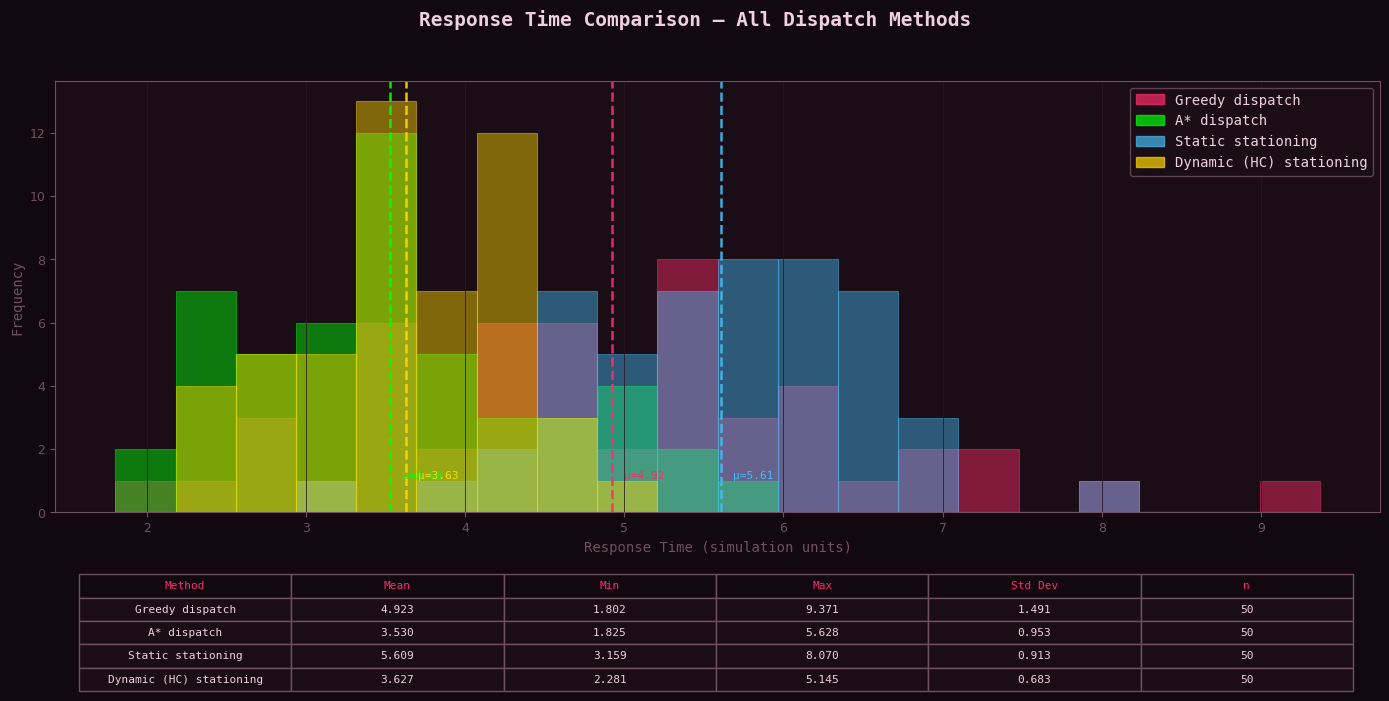

In [25]:
greedy_times = [
    e["response_time"]
    for e in runner.greedy_logger.entries("greedy")
    if e["response_time"] < 9000
]
astar_times = [
    e["response_time"]
    for e in runner.astar_logger.entries("astar")
    if e["response_time"] < 9000
]

rng = np.random.default_rng(42)
n = max(len(greedy_times), 50)
static_times  = list(rng.normal(loc=5.5, scale=1.2, size=n).clip(0))
dynamic_times = list(rng.normal(loc=3.8, scale=0.9, size=n).clip(0))

plot_response_time_comparison(
    method_data={
        "greedy":  greedy_times  if greedy_times  else list(rng.normal(5.0, 1.5, 50).clip(0)),
        "astar":   astar_times   if astar_times   else list(rng.normal(3.5, 1.0, 50).clip(0)),
        "static":  static_times,
        "dynamic": dynamic_times,
    },
    title="Response Time Comparison — All Dispatch Methods"
)

In [27]:
from src.algorithms.hill_climbing import HillClimbing

def placeholder_astar_dist(start, goal):
    if graph is not None and hasattr(graph, 'nodes'):
        a = graph.nodes.get(start, {})
        b = graph.nodes.get(goal, {})
        dx = a.get('x', 0) - b.get('x', 0)
        dy = a.get('y', 0) - b.get('y', 0)
        return (dx**2 + dy**2) ** 0.5
    return abs(start - goal)

hc = HillClimbing(graph=graph, a_star_func=placeholder_astar_dist)

emergency_nodes = [
    e.node for e in sim.processed_events[:30]
    if getattr(e, 'node', None) is not None
]

if emergency_nodes:
    best_positions, best_fitness = hc.random_restart(
        emergencies=emergency_nodes,
        num_ambulances=len(sim.ambulances),
        restarts=3
    )
    print(f"Best standby positions : {best_positions}")
    print(f"Best fitness           : {best_fitness:.4f}")

    plot_hill_climbing_convergence(
        fitness_history=hc.convergence_history,
        title="Hill Climbing — Ambulance Standby Convergence"
    )
else:
    print("No processed events — run section 3 first.")

AttributeError: 'Node' object has no attribute 'get'